# PROJECT3 (MATH214)
## MUHAMMET ALİ AYVAZ
## 210102002078

In [10]:
import numpy as np  # LineSpace için
from matplotlib import pyplot as plt  # Grafik çizimleri için
import math  # Matematiksel işlemler için

A) In Section A, the required functions are provided, and the task involves plotting and displaying these functions in both polar and Cartesian coordinates using a computer. Additionally, the Cartesian representation should include orthogonal vectors. A detailed explanation of this process is provided below.

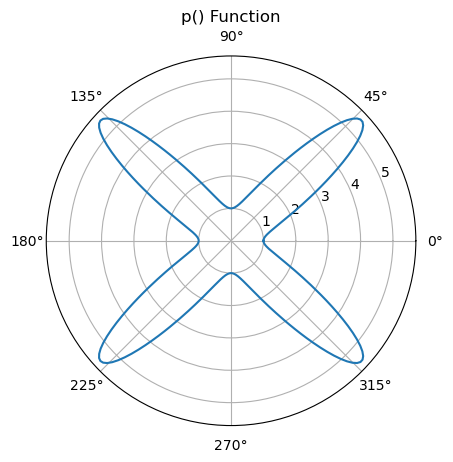

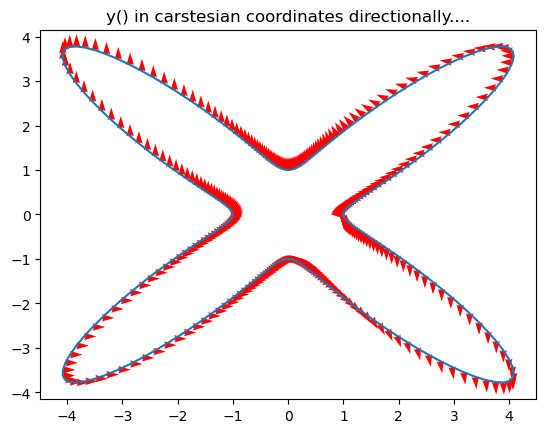

In [11]:
# Polar grafik fonksiyonu
def p(x):  # x radyan cinsinden. (Rapordaki p fonksiyonu)
    y1 = abs(math.cos(x))**8
    y2 = abs(math.sin(x))**6
    rval = (y1 + y2)**(-1)
    return rval

# x değerlerini oluşturuyoruz (0 ile 2π arasında 360 eşit aralık)
x_values = np.linspace(0, 2 * np.pi, 360)

# y değerlerini hesaplıyoruz
y_values = []
for i in range(0, len(x_values)):  # p fonksiyonuna göre y değerlerini ekliyoruz
    y_values.append(p(x_values[i]))

# Polar grafik oluşturma
plt.subplot(1, 1, 1, projection='polar')  # Polar grafik için
plt.plot(x_values, y_values)  # x ve y değerlerini çiz
plt.title("p() Function")  # Başlık
plt.show()  # Grafiği göster
#for cartesian graph....

def v_vector(x): # t_vector produces vertical vectors
    def dx_dx(x):
        y = -(3/4) * ((np.abs(np.cos(3*x/4)))**7) * np.sign(np.cos(3*x/4))
        return y
    def dy_dx(x):
        y = (3/4) * ((np.abs(np.sin(3*x/4)))**7) * np.sign(np.sin(3*x/4))
        return y
    dx_dx1 = dx_dx(x)
    dy_dx1 = dy_dx(x)
    l = np.sqrt(dx_dx1**2 + dy_dx1**2)
    ax = dx_dx1 / l
    ay = dy_dx1 / l
    return ax, ay


def calculate_coordinates(x_values, y_values): # the function in the report 
    x_values_c = y_values * np.cos(x_values)
    y_values_c = y_values * np.sin(x_values)
    return x_values_c, y_values_c


t_vectors = []

for i in range(0,len(x_values)): # adding vertical vectors..
    t_vectors.append(v_vector(x_values[i]))

t_vector_x = []
t_vector_y = []

for i in range(0, len(t_vectors)):
    t_vector_x.append(t_vectors[i][0])
    t_vector_y.append(t_vectors[i][1])

plt.subplot(1, 1, 1) #visualizing for the graph
x_values_c, y_values_c = calculate_coordinates(x_values, y_values)
plt.plot(x_values_c, y_values_c, label='y()')

for i in range(len(x_values_c)):
    plt.quiver(x_values_c[i], y_values_c[i], t_vector_x[i], t_vector_y[i], color='red', scale=40)
    

plt.title('y() in carstesian coordinates directionally....')
plt.show()

B) In Section B, the objective is to calculate the derivatives \( \frac{dx}{dp} \), \( \frac{dx}{dx} \), and the function \( L(x) \) using the given functions \( p(x) \), \( x \), and \( y \). Additionally, plotting these derivatives and the function is required. This is achieved using the Forward Difference, Backward Difference, Three-Point Endpoint, and Three-Point Midpoint formulas applied separately. The finalized version of these tasks is provided below, with detailed explanations included as comment lines.

In [12]:
def newton_forward(f, x, h): #newton forward formula
    der_val = (f(x + h) - f(x)) / h
    return der_val

def newton_backward(f, x, h): #newton backward formula 
    der_val = (f(x) - f(x - h)) / h
    return der_val

def three_point_midpoint(f, x, h): #three point midpoint formula
    der_val = (f(x + h) - f(x - h)) / (2 * h)
    return der_val

def three_point_endpoint(f, x, h): #three point endpoint formula
    der_val = (-3 * f(x) + 4 * f(x + h) - f(x + 2 * h)) / (2 * h)
    return der_val

h= 0.0000000001  #smal h value (to approximate)

# fiind_numeric_and_show function finds df/dx according to newton forward, backward... and function which is send, after that shows the graph .
#if true ==> return that y_values, if not only shows the graph.The reason for using x is for seciton d
def find_numeric_and_show(function, y_label, label = False):  
    
    df_dx_values1 = []
    df_dx_values2 = []
    df_dx_values3 = []
    df_dx_values4 = []
    for i in range(0, len(x_values)): #applying methods according to the sent function...
        df_dx_values1.append(newton_forward(function, x_values[i], h))
        df_dx_values2.append(newton_backward(function, x_values[i], h))
        df_dx_values3.append(three_point_midpoint(function, x_values[i], h))
        df_dx_values4.append(three_point_endpoint(function, x_values[i], h))
    
    if (label):
        return df_dx_values3
    #create the graph
    plt.figure(figsize=(10, 6))

    plt.plot(x_values, df_dx_values1, color="blue", linewidth=2, label="NEWTON FORWARD" )
    plt.plot(x_values, df_dx_values2, color="green", linewidth=2, label="NEWTON BACKWARD" )
    plt.plot(x_values, df_dx_values3, color="pink", linewidth=2, label="THREE POINT MIDPOINT" )
    plt.plot(x_values, df_dx_values4, color="red", linewidth=2, label="THREE POINT ENDPOINT" )

    plt.title('Numeric Derivatives')
    plt.xlabel('x')
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True)
    plt.show()
    
#creating desired functions ...

The functions dp/dx, dy/dx, and L(x) obtained using the forward difference, backward difference, 
three-point endpoint, three-point midpoint, and three-point central difference formulas are 
overlaid in the graph below.

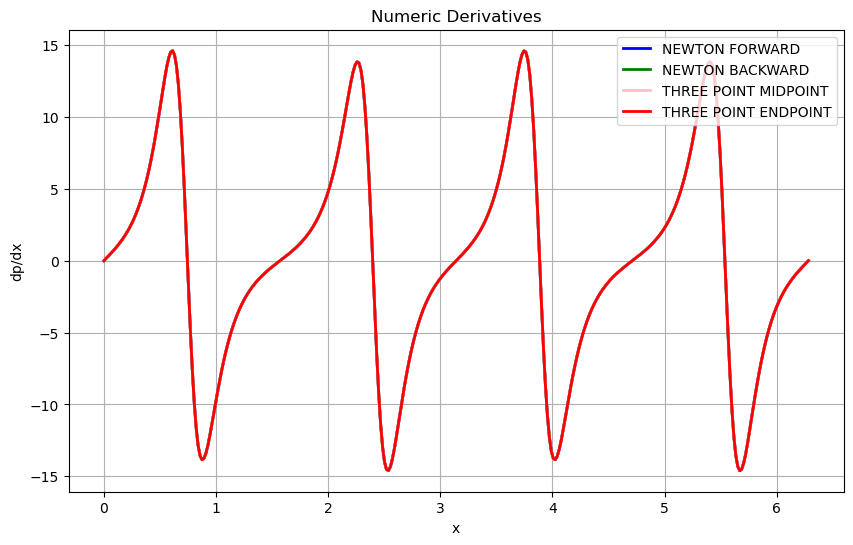

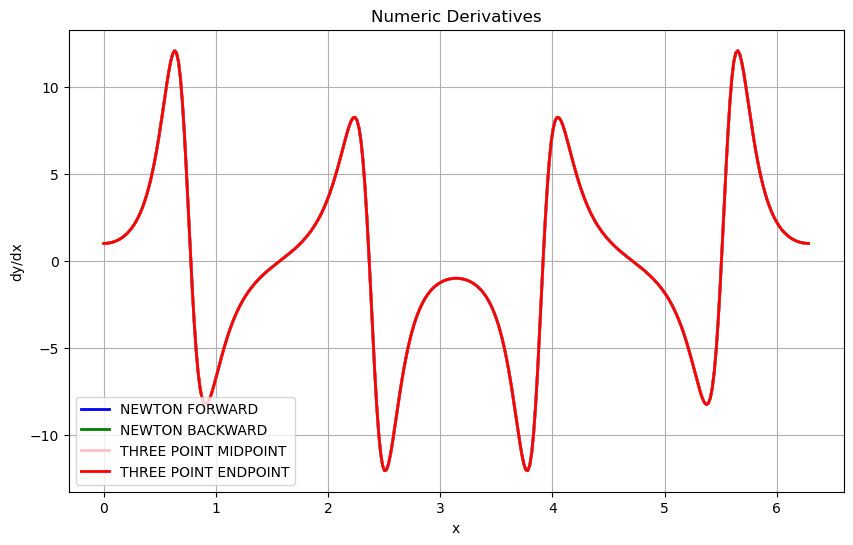

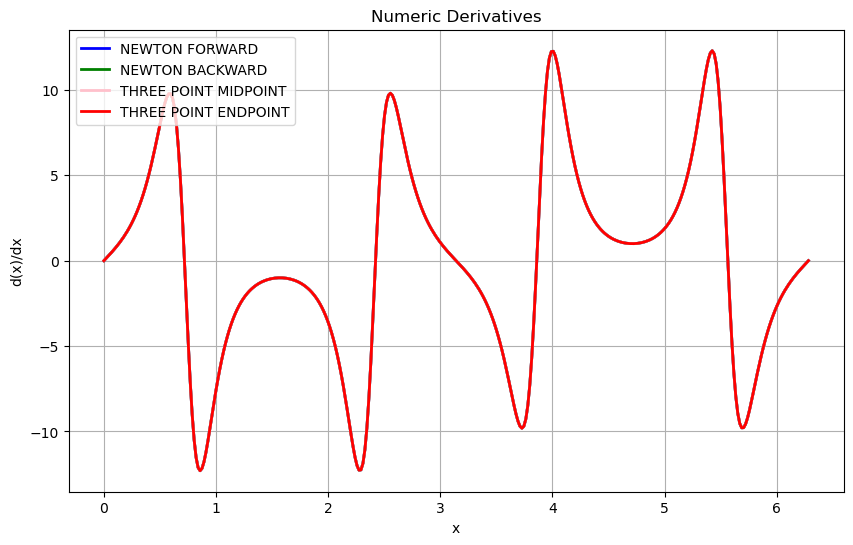

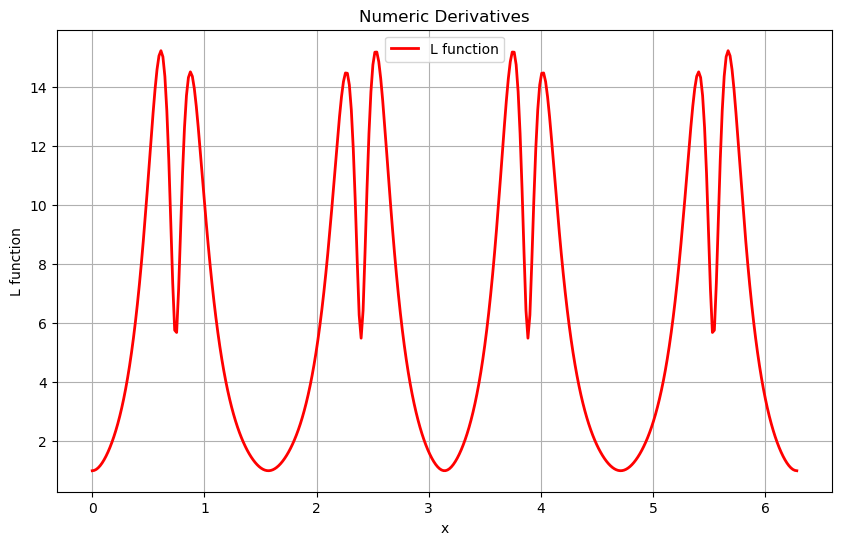

In [13]:
#for dp/dx:
find_numeric_and_show(p, "dp/dx")
dp_dx_list = find_numeric_and_show(p, "empty", True) #for using d section...
#for dy/dx:
def y_function(x):
    y = p(x) * np.sin(x)
    return y
find_numeric_and_show(y_function, "dy/dx")
dy_dx_list = find_numeric_and_show(y_function, "empty", True) #for using (d) section...
#for d(x)/dx
def x_function(x):
    x = p(x) * np.cos(x)
    return x
find_numeric_and_show(x_function, "d(x)/dx")
dx_dx_list = find_numeric_and_show(x_function, "empty", True)
#for L(x):
dx_x = find_numeric_and_show(x_function, "empty", True)
dy_dx = find_numeric_and_show(y_function, "empty", True)
sum_list = []
for i in range(0, len(x_values)):
    sum_list.append(np.sqrt(dx_x[i]**2 + dy_dx[i]**2))
    
#show l(x) function.

plt.figure(figsize=(10, 6))
plt.plot(x_values, sum_list, color="red", linewidth=2, label="L function" )
plt.title('Numeric Derivatives')
plt.xlabel('x')
plt.ylabel("L function")
plt.legend()
plt.grid(True)
plt.show()

As seen, the functions obtained with the four methods overlap, indicating that there is not much 
difference between the four methods.

C) In Section C, it is stated that the Hermite function has been determined, but only the y-values of the Hermite function were calculated. However, the task requires finding the \( p(x) \) function. To address this, the coefficients of the Hermite function were calculated piecewise and printed. Subsequently, with the assistance of AI (ChatGPT), these printed piecewise functions were transformed into an array and written in functional form. As a result, we now have the piecewise Hermite(x) function, which approximates the values of \( p(x) \). 

(Note: ChatGPT was used because the functions are too complex and lengthy for manual input.)

x = 0.0, 1.0 *(1 + 2 * t) * (1 - t)**2, 3.44938862178501* t * (1 - t)**2, 4.44938862178501* t**2 * (3 - 2 * t), 3.44938862178501* t**2 * (t - 1)
x = 0.6283185307179586, 4.44938862178501 *(1 + 2 * t) * (1 - t)**2, -3.098208488409944* t * (1 - t)**2, 1.351180133375066* t**2 * (3 - 2 * t), -3.098208488409944* t**2 * (t - 1)
x = 1.2566370614359172, 1.351180133375066 *(1 + 2 * t) * (1 - t)**2, -1.1102230246251565e-15* t * (1 - t)**2, 1.3511801333750648* t**2 * (3 - 2 * t), -1.1102230246251565e-15* t**2 * (t - 1)
x = 1.8849555921538759, 1.3511801333750648 *(1 + 2 * t) * (1 - t)**2, 3.0982084884099472* t * (1 - t)**2, 4.449388621785013* t**2 * (3 - 2 * t), 3.0982084884099472* t**2 * (t - 1)
x = 2.5132741228718345, 4.449388621785013 *(1 + 2 * t) * (1 - t)**2, -3.4493886217850127* t * (1 - t)**2, 1.0* t**2 * (3 - 2 * t), -3.4493886217850127* t**2 * (t - 1)
x = 3.7699111843077517, 4.449388621785012 *(1 + 2 * t) * (1 - t)**2, -3.098208488409946* t * (1 - t)**2, 1.351180133375066* t**2 * (3 - 2 * 

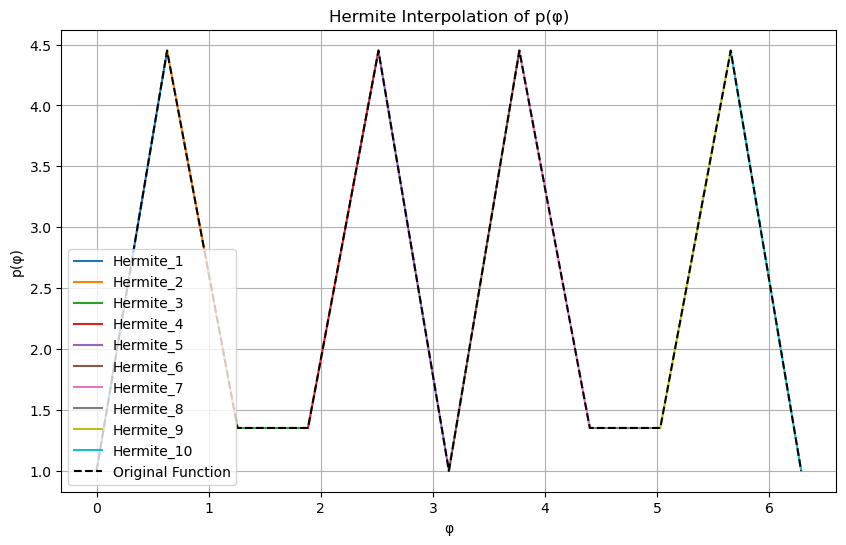

In [14]:
try_list = []

#Calculating 3rd-degree Hermite interpolation
def hermite_interpolation(x_start, x_end, y_start, y_end, slope_start, slope_end, x_value):
    t = (x_value - x_start) / (x_end - x_start)
    h00 = (1 + 2 * t) * (1 - t)**2
    h10 = t * (1 - t)**2
    h01 = t**2 * (3 - 2 * t)
    h11 = t**2 * (t - 1)
    
    if y_start not in try_list: #for observing section d , to collect form of formula
        try_list.append(y_start)
        print("x = {}, {} *(1 + 2 * t) * (1 - t)**2, {}* t * (1 - t)**2, {}* t**2 * (3 - 2 * t), {}* t**2 * (t - 1)".format(x,y_start,(x_end - x_start)* slope_start,y_end,(x_end - x_start) * slope_end   ) )
    return h00 * y_start + h10 * (x_end - x_start) * slope_start + h01 * y_end + h11 * (x_end - x_start) * slope_end


N = 10 # subintervals N
x_division = np.linspace(0, 2 * np.pi, N + 1)  

plt.figure(figsize=(10, 6))

# Calculating the required values for Hermite interpolation while iterating over subintervals....
for i in range(N):
    x0, x1 = x_division[i], x_division[i + 1]
    p0, p1 = p(x0), p(x1)
    dp0, dp1 = (p(x1) - p(x0)) / (x1 - x0), (p(x1) - p(x0)) / (x1 - x0)
    
    x_vals = np.linspace(x0, x1, 100)
    # Calculating Hermite interpolation at each point...
    p_vals = []
    for x in x_vals:
        p_vals.append(hermite_interpolation(x0, x1, p0, p1, dp0, dp1, x))
    
    # shows each  Hermite interpolation....
    plt.plot(x_vals, p_vals, label='Hermite_{}'.format(i + 1))

real_values = []
for x in x_division:
    real_values.append(p(x))

plt.plot(x_division, real_values, label='Original Function', linestyle='--', color='black')

# for graph
plt.title('Hermite Interpolation of p(φ)')
plt.xlabel('φ')
plt.ylabel('p(φ)')
plt.legend()
plt.grid(True)
plt.show()

Based on the provided graph, the piecewise Hermite functions closely align with the original \( p(x) \) function, as evidenced by the overlapping lines. This indicates a high level of accuracy and no noticeable error between the Hermite interpolation and the actual \( p(x) \) values. When experimenting with different values of \( n \) (the number of interpolation points), it can be observed that as \( n \) decreases, the approximation diverges more significantly from the original function. This demonstrates that higher \( n \) values result in better interpolation accuracy, while lower \( n \) values reduce the precision of the Hermite approximation.

D) In Section D, the task is to rediscover dp/dx, dy/dx, dx/dx, and L(x) functions using the obtained 
Hermite function. These functions, along with the actual p(x) functions, are overlaid, and the 
relative error is determined

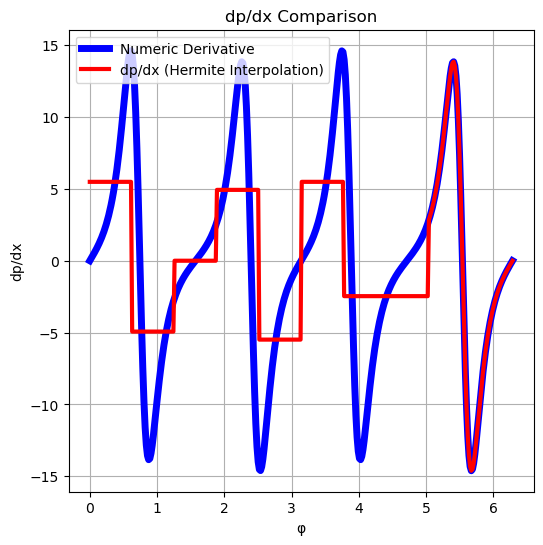

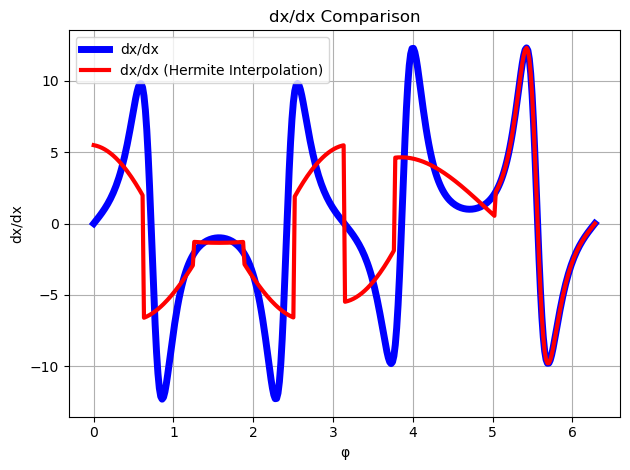

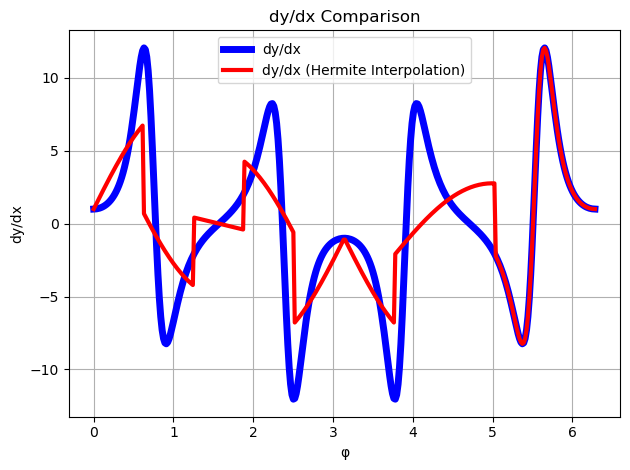

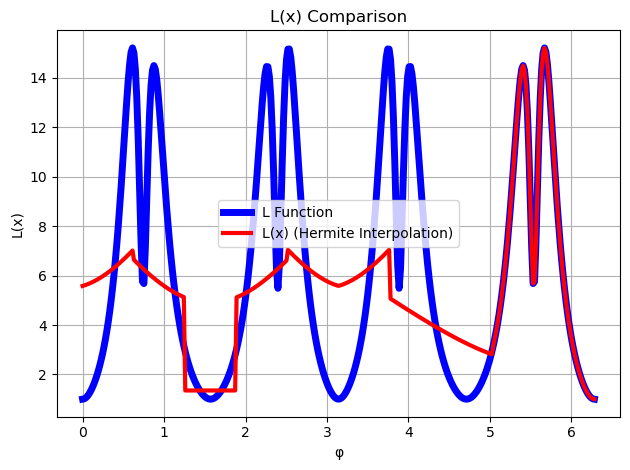

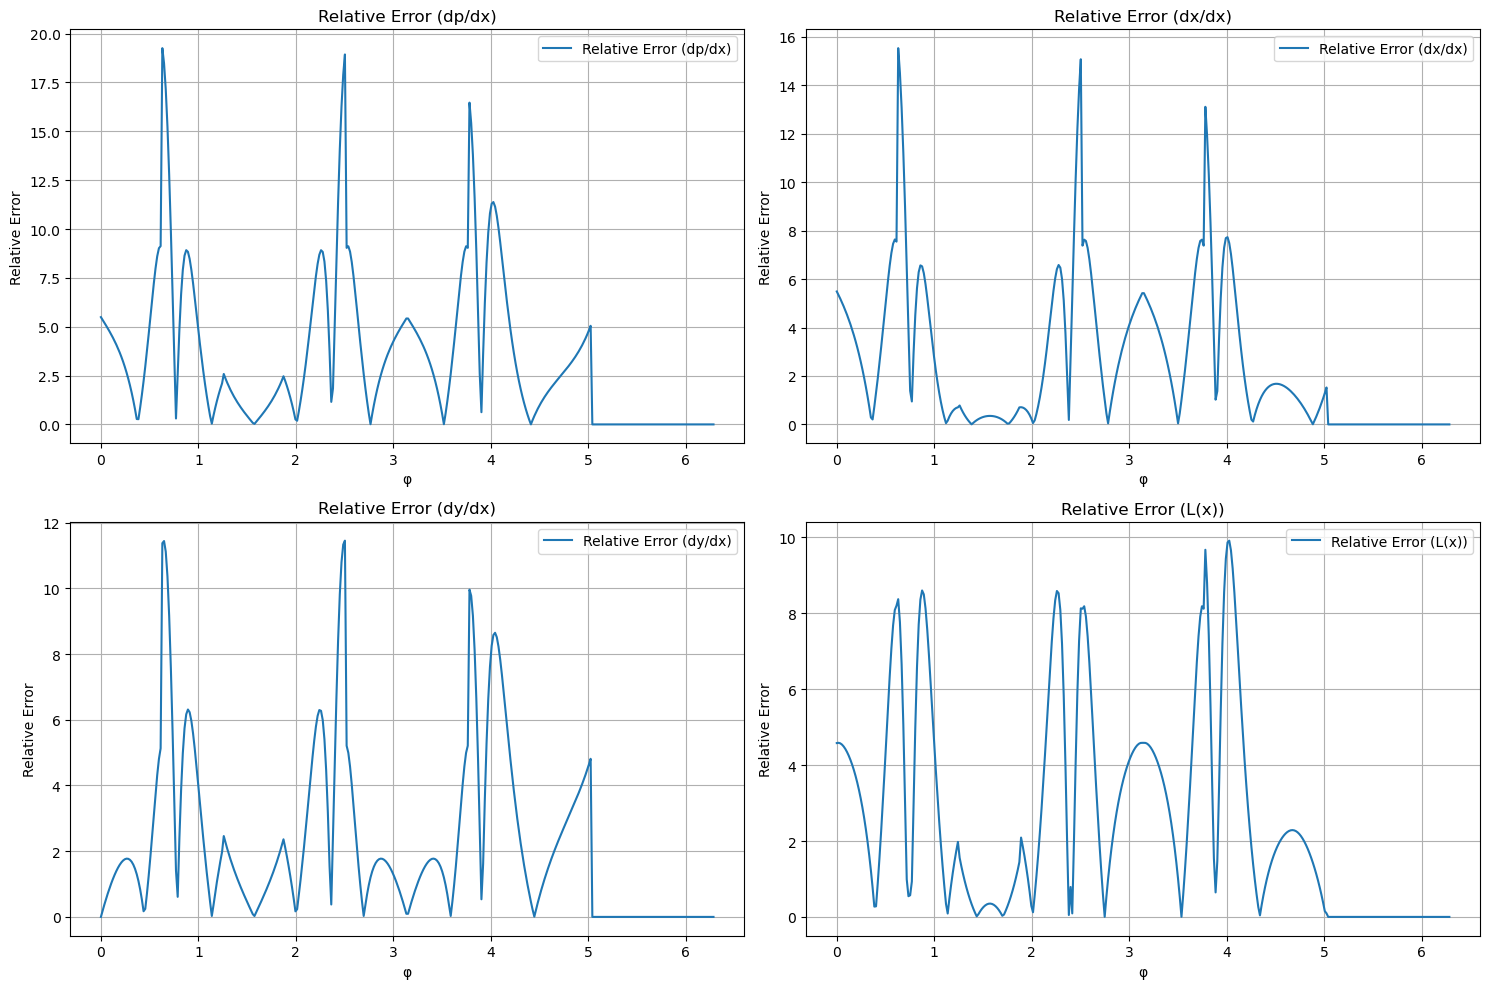

In [15]:
# the printed outputs were copied and transformed into an array in AI. Later, the piecewise_hermit_f function was obtained below.

def piecewise_hermit_f(x):
    x_division = [0, 0.6283185307179586, 1.2566370614359172, 1.8849555921538759, 2.5132741228718345, 3.141592653589793, 3.7699111843077517, 5.026548245743669]
    
    for i in range(len(x_division) - 1):
        x0, x1 = x_division[i], x_division[i + 1]
        if x0 <= x <= x1:
            p0, p1 = p(x0), p(x1)
            dp0, dp1 = (p(x1) - p(x0)) / (x1 - x0), (p(x1) - p(x0)) / (x1 - x0)
            t = (x - x0) / (x1 - x0)
            h00 = (1 + 2 * t) * (1 - t)**2
            h10 = t * (1 - t)**2
            h01 = t**2 * (3 - 2 * t)
            h11 = t**2 * (t - 1)
            return h00 * p0 + h10 * (x1 - x0) * dp0 + h01 * p1 + h11 * (x1 - x0) * dp1

    return p(x)  # Default: return p(x) if x is outside the specified range

def x_function_H(x): #it is created to obtain x function of hermit
    return piecewise_hermit_f(x) * np.cos(x)
def y_function_H(x): #it is created to obtain y function of hermit
    return piecewise_hermit_f(x) * np.sin(x)
def calculate_derivative(f, x): # calculating a derivative of any function with name of the function....
    h = 1e-10
    return (f(x + h) - f(x)) / h
def L_function_H(x): #it is created to obtain l(x) function....
    return (calculate_derivative(x_function_H, (x))**2 + calculate_derivative(y_function_H, (x))**2)**0.5

#obtaining the functions by using hermit formula
#for dp/dx:
y_val_dp_dx = []
for i in range(0, len(x_values)):
    y_val_dp_dx.append(calculate_derivative(piecewise_hermit_f, x_values[i]))
#for dx_dx:
y_val_dx_dx = []
for i in range(0, len(x_values)):
    y_val_dx_dx.append(calculate_derivative(x_function_H, x_values[i]))
#for dy_dx:
y_val_dy_dx = []
for i in range(0, len(x_values)):
    y_val_dy_dx.append(calculate_derivative(y_function_H, x_values[i]))
#for L function : 
y_val_L =[]
for i in range(0, len(x_values)):
    y_val_L.append(L_function_H(x_values[i]))

#shows graphs : 

plt.figure(figsize=(6, 6))
plt.plot(x_values, dp_dx_list, label='Numeric Derivative',  color="blue", linewidth=5)
plt.title('Numeric Derivative of p(φ)')
plt.xlabel('φ')
plt.ylabel('dp/dx')
plt.legend()
plt.grid(True)
plt.plot(x_values, y_val_dp_dx, label='dp/dx (Hermite Interpolation)',  color="red", linewidth=3)
plt.title('dp/dx Comparison')
plt.xlabel('φ')
plt.ylabel('dp/dx')
plt.legend()
plt.grid(True)
plt.show()

#****************************************

plt.plot(x_values, dx_dx_list, label='dx/dx',  color="blue", linewidth=5)
plt.title('dx/dx')
plt.xlabel('φ')
plt.ylabel('dx/dx')
plt.legend()
plt.grid(True)
plt.plot(x_values, y_val_dx_dx, label='dx/dx (Hermite Interpolation)',  color="red", linewidth=3)
plt.title('dx/dx Comparison')
plt.xlabel('φ')
plt.ylabel('dx/dx')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
#****************************************

plt.plot(x_values, dy_dx_list, label='dy/dx',  color="blue", linewidth=5)
plt.title('dy/dx')
plt.xlabel('φ')
plt.ylabel('dy/dx')
plt.legend()
plt.grid(True)
plt.plot(x_values, y_val_dy_dx, label='dy/dx (Hermite Interpolation)',  color="red", linewidth=3)
plt.title('dy/dx Comparison')
plt.xlabel('φ')
plt.ylabel('dy/dx')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#****************************************

plt.plot(x_values, sum_list, label='L Function',  color="blue", linewidth=5)
plt.title('L(x)')
plt.xlabel('φ')
plt.ylabel('L(x)')
plt.legend()
plt.grid(True)
plt.plot(x_values, y_val_L, label='L(x) (Hermite Interpolation)',  color="red", linewidth=3)
plt.title('L(x) Comparison')
plt.xlabel('φ')
plt.ylabel('L(x)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# calculating relative errros....

r_e_dp_dx = np.abs(np.array(dp_dx_list) - np.array(y_val_dp_dx))
r_e_dx_dx = np.abs(np.array(dx_dx_list) - np.array(y_val_dx_dx))
r_e_dy_dx = np.abs(np.array(dy_dx_list) - np.array(y_val_dy_dx))
r_e_L = np.abs(np.array(sum_list) - np.array(y_val_L))

# showing graphs(relative errors)...

plt.figure(figsize=(15, 10))

# for dp/dx 

plt.subplot(2, 2, 1)
plt.plot(x_values, r_e_dp_dx, label='Relative Error (dp/dx)')
plt.title('Relative Error (dp/dx)')
plt.xlabel('φ')
plt.ylabel('Relative Error')
plt.legend()
plt.grid(True)

# for dx/dx 
plt.subplot(2, 2, 2)
plt.plot(x_values, r_e_dx_dx, label='Relative Error (dx/dx)')
plt.title('Relative Error (dx/dx)')
plt.xlabel('φ')
plt.ylabel('Relative Error')
plt.legend()
plt.grid(True)

# for dy/dx
plt.subplot(2, 2, 3)
plt.plot(x_values, r_e_dy_dx, label='Relative Error (dy/dx)')
plt.title('Relative Error (dy/dx)')
plt.xlabel('φ')
plt.ylabel('Relative Error')
plt.legend()
plt.grid(True)

# for L(x) 
plt.subplot(2, 2, 4)
plt.plot(x_values, r_e_L, label='Relative Error (L(x))')
plt.title('Relative Error (L(x))')
plt.xlabel('φ')
plt.ylabel('Relative Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


E-F)  In Section e and f, it is requested to find all functions, previously obtained using the Hermite 
method in Section D, with the cubic spline method instead. However, this is a more challenging 
problem than Hermite because the boundaries of piecewise functions have extremely large 
slope values for both the function and its derivative. It has been determined through trial and 
error that dividing the interval [0, 2π] into 85 segments, rather than 360, is the most optimized 
approach. Additionally, various online research has been conducted, and it has been identified 
that the tridiagonal matrix algorithm is one of the best methods for solving this problem. The 
necessary references have been added to the end of the report. This algorithm has been adapted
 and edited with ChatGPT, resulting in the creation of the derivative_cubic(x) and cubic_formula 
functions. Subsequently, graphs along with error rates have been presented

S'0(x) = 0.3028557784588177  for  0.0 <= x <= 0.07479982508547127
S'1(x) = 0.3028557784588177  for  0.07479982508547127 <= x <= 0.14959965017094254
S'2(x) = -1.7343013893910024  for  0.14959965017094254 <= x <= 0.2243994752564138
S'3(x) = 16.45458141992645  for  0.2243994752564138 <= x <= 0.2991993003418851
S'4(x) = -4.0749550767787  for  0.2991993003418851 <= x <= 0.37399912542735636
S'5(x) = 31.686492661278407  for  0.37399912542735636 <= x <= 0.4487989505128276
S'6(x) = 0.4225076244654531  for  0.4487989505128276 <= x <= 0.5235987755982989
S'7(x) = 53.83208357016086  for  0.5235987755982989 <= x <= 0.5983986006837702
S'8(x) = -0.3327011799575246  for  0.5983986006837702 <= x <= 0.6731984257692414
S'9(x) = 25.03208234551694  for  0.6731984257692414 <= x <= 0.7479982508547127
S'10(x) = -105.5533368110467  for  0.7479982508547127 <= x <= 0.822798075940184
S'11(x) = -17.001715012641228  for  0.822798075940184 <= x <= 0.8975979010256552
S'12(x) = -53.38337665694516  for  0.89759790102565

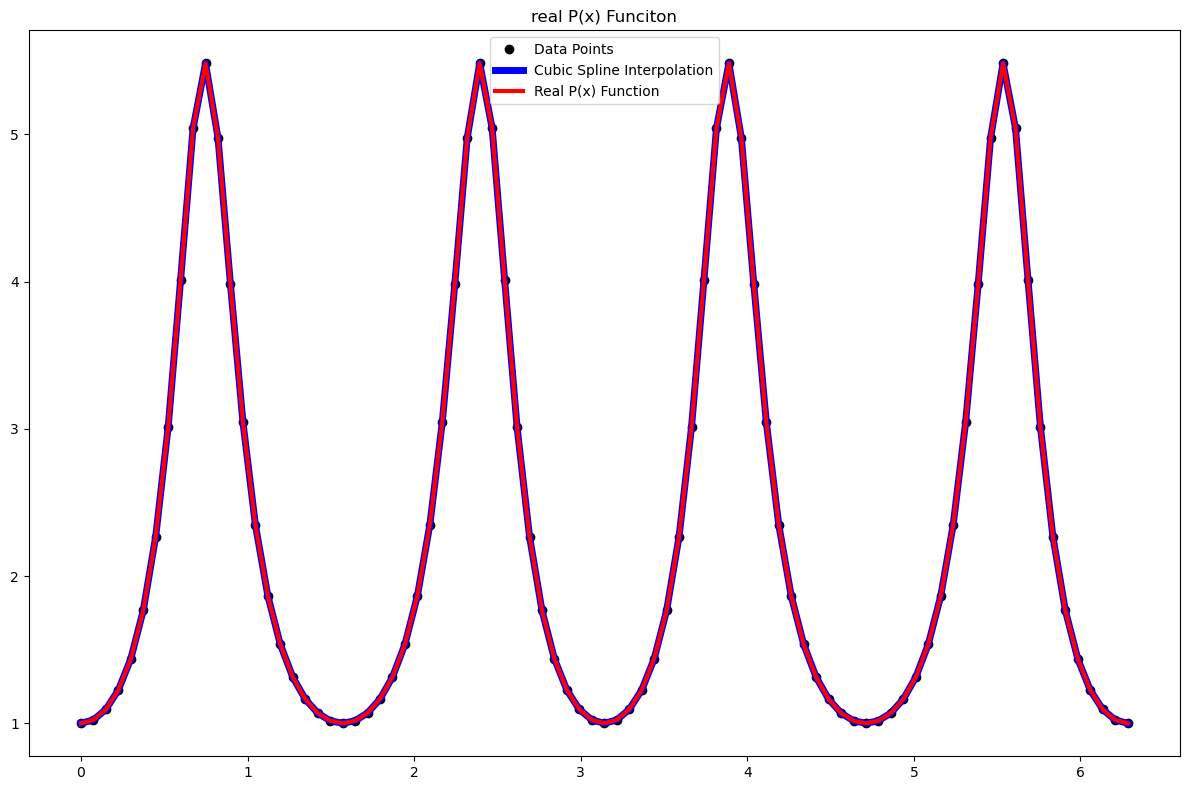

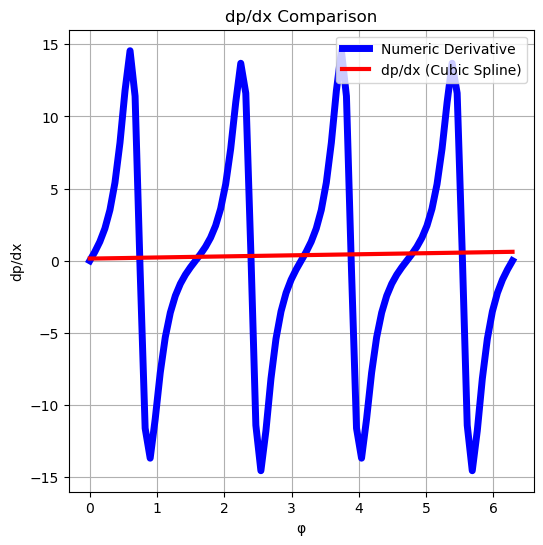

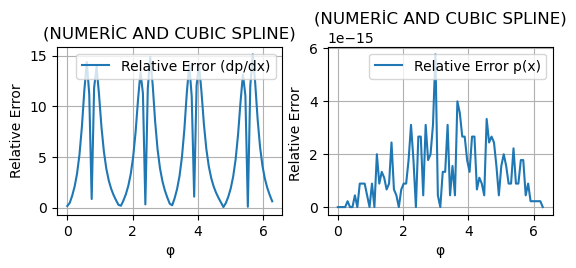

In [16]:
# Cubic spline interpolation function
def cubic_spline_interpolation(x, y, x_interp):
    # Get the number of data points
    n = len(x)
    
    # Calculate the distances h between data points
    h = np.diff(x)
    
    # Calculate the differences in y values between data points
    delta_y = np.diff(y)
    
    # Calculate the derivative alpha for each h distance
    alpha = delta_y / h
    
    # Allocate space for the lower triangle of the tridiagonal matrix
    l = np.zeros(n)
    mu = np.zeros(n)
    z = np.zeros(n)
    
    # Manually set the first element
    l[1] = 3 * (alpha[1] - alpha[0]) / (h[1] + h[0])

    # Calculate the remaining elements with a for loop
    for i in range(2, n-1):
        l[i] = 3 * (alpha[i] - alpha[i-1]) / (h[i] + h[i-1])
        mu[i] = h[i-1] / (h[i-1] + h[i] - h[i-1] * mu[i-1])
        z[i] = (l[i] - h[i-1] * z[i-1]) / (h[i-1] + h[i] - h[i-1] * mu[i-1])
    
    # Calculate spline coefficients
    l_c_e = np.zeros(n) 
    c_c_e = np.zeros(n)
    d_c_e = np.zeros(n)
    
    for j in range(n-2, 0, -1):
        c_c_e[j] = z[j] - mu[j] * c_c_e[j+1]
        l_c_e[j] = alpha[j] - (alpha[j-1] - l_c_e[j-1]) * mu[j]
        d_c_e[j] = (c_c_e[j+1] - c_c_e[j]) / (3 * h[j])
    
    # Calculate the b coefficients
    b_c_e = alpha - h * (c_c_e[1:] + 2 * c_c_e[:-1]) / 3
    
    interpolated_values = np.zeros_like(x_interp)
    
    # Perform interpolation for each x_interp value
    for i in range(len(x_interp)):
        # Determine the interval in which x_interp lies
        index = np.searchsorted(x, x_interp[i])
        index = np.clip(index - 1, 0, n-2).astype(int)
        
        # Calculate the first, second, third, and fourth-degree terms based on the x value in the respective interval
        dx = x_interp[i] - x[index]
        interpolated_values[i] = y[index] + b_c_e[index] * dx + c_c_e[index] * dx**2 + d_c_e[index] * dx**3
    
    # Print the cubic spline interpolation function
    derivative_values = np.zeros_like(x_interpolation_points)

    for i in range(len(x_interpolation_points)):
        # Determine the interval in which x_interp lies
        index = np.searchsorted(x_values, x_interpolation_points[i])
        index = np.clip(index - 1, 0, len(x_values)-2).astype(int)

        # Calculate the derivative using the coefficients of the cubic spline in the respective interval
        dx = x_interpolation_points[i] - x_values[index]
        derivative_values[i] = b_c_e[index] + 2 * c_c_e[index] * dx + 3 * d_c_e[index] * dx**2

    # Prints the derivative values to collect values to obtain the formula....
    for j in range(len(x_values)-1):
        print(f"S'{j}(x) = {derivative_values[j]}  for  {x_values[j]} <= x <= {x_values[j+1]}")
    
    for j in range(n-1): # prints the y values to collect to obtain the formula...
        print(f"S{j}(x) = {y[j]} + {b_c_e[j]} * (x - {x[j]}) + {c_c_e[j]} * (x - {x[j]})^2 + {d_c_e[j]} * (x - {x[j]})^3  for  {x[j]} <= x <= {x[j+1]}")
    
    return interpolated_values

# that derivative_cubic function is obtained with chatgpt to do array.
# in 443.row, it is printed 
def derivative_cubic(x):
    coefficients = [
        (0.0, 0.07479982508547127, 0.1532), 
        (0.07479982508547127, 0.14959965017094254, 0.1587),
        (0.14959965017094254, 0.2243994752564138, 0.1641), 
        (0.2243994752564138, 0.2991993003418851, 0.1696),
        (0.2991993003418851, 0.37399912542735636, 0.1750),
        (0.37399912542735636, 0.4487989505128276, 0.1805),
        (0.4487989505128276, 0.5235987755982989, 0.1859),
        (0.5235987755982989, 0.5983986006837702, 0.1923),
        (0.5983986006837702, 0.6731984257692414, 0.1987),
        (0.6731984257692414, 0.7479982508547127, 0.2052),
        (0.7479982508547127, 0.822798075940184, 0.2116),
        (0.822798075940184, 0.8975979010256552, 0.2179),
        (0.8975979010256552, 0.9723977261111265, 0.2234),
        (0.9723977261111265, 1.0471975511965979, 0.2290),
        (1.0471975511965979, 1.121997376282069, 0.2345),
        (1.121997376282069, 1.1967972013675403, 0.2401),
        (1.1967972013675403, 1.2715970264530116, 0.2457),
        (1.2715970264530116, 1.3463968515384828, 0.2512),
        (1.3463968515384828, 1.421196676623954, 0.2568),
        (1.421196676623954, 1.4959965017094254, 0.2623),
        (1.4959965017094254, 1.5707963267948966, 0.2679),
        (1.5707963267948966, 1.645596151880368, 0.2734),
        (1.645596151880368, 1.7203959769658392, 0.2789),
        (1.7203959769658392, 1.7951958020513104, 0.2845),
        (1.7951958020513104, 1.8699956271367817, 0.2900),
        (1.8699956271367817, 1.944795452222253, 0.2956),
        (1.944795452222253, 2.019595277307724, 0.3011),
        (2.019595277307724, 2.0943951023931957, 0.3067),
        (2.0943951023931957, 2.169194927478667, 0.3122),
        (2.169194927478667, 2.243994752564138, 0.3178),
        (2.243994752564138, 2.3187945776496095, 0.3233),
        (2.3187945776496095, 2.3935944027350806, 0.3289),
        (2.3935944027350806, 2.4683942278205517, 0.3344),
        (2.4683942278205517, 2.5431940529060233, 0.3399),
        (2.5431940529060233, 2.6179938779914944, 0.3455),
        (2.6179938779914944, 2.6927937030769655, 0.3510),
        (2.6927937030769655, 2.767593528162437, 0.3566),
        (2.767593528162437, 2.842393353247908, 0.3621),
        (2.842393353247908, 2.9171931783333793, 0.3677),
        (2.9171931783333793, 2.991993003418851, 0.3732),
        (2.9171931783333793, 2.991993003418851, 0.3732),
        (2.991993003418851, 3.066792828504322, 0.3788),
        (3.066792828504322, 3.141592653589793, 0.3843),
        (3.141592653589793, 3.2163924786752647, 0.3899),
        (3.2163924786752647, 3.291192303760736, 0.3954),
        (3.291192303760736, 3.365992128846207, 0.4010),
        (3.365992128846207, 3.4407919539316785, 0.4065),
        (3.4407919539316785, 3.5155917790171496, 0.4121),
        (3.5155917790171496, 3.5903916041026207, 0.4176),
        (3.5903916041026207, 3.6651914291880923, 0.4232),
        (3.6651914291880923, 3.7399912542735634, 0.4287),
        (3.7399912542735634, 3.814791079359035, 0.4343),
        (3.814791079359035, 3.889590904444506, 0.4398),
        (3.889590904444506, 3.964390729529977, 0.4454),
        (3.964390729529977, 4.039190554615448, 0.4510),
        (4.039190554615448, 4.11399037970092, 0.4565),
        (4.11399037970092, 4.188790204786391, 0.4621),
        (4.188790204786391, 4.263590029871862, 0.4676),
        (4.263590029871862, 4.338389854957334, 0.4732),
        (4.338389854957334, 4.413189680042805, 0.4787),
        (4.413189680042805, 4.487989505128276, 0.4843),
        (4.487989505128276, 4.562789330213747, 0.4898),
        (4.562789330213747, 4.637589155299219, 0.4954),
        (4.637589155299219, 4.71238898038469, 0.5010),
        (4.71238898038469, 4.787188805470161, 0.5065),
        (4.787188805470161, 4.861988630555633, 0.5121),
        (4.861988630555633, 4.9367884556411035, 0.5176),
        (4.9367884556411035, 5.011588280726575, 0.5232),
        (5.011588280726575, 5.086388105812047, 0.5287),
        (5.086388105812047, 5.161187930897517, 0.5343),
        (5.161187930897517, 5.235987755982989, 0.5398),
        (5.235987755982989, 5.31078758106846, 0.5454),
        (5.31078758106846, 5.385587406153931, 0.5510),
        (5.385587406153931, 5.460387231239403, 0.5565),
        (5.460387231239403, 5.535187056324874, 0.5621),
        (5.535187056324874, 5.609986881410345, 0.5676),
        (5.609986881410345, 5.684786706495816, 0.5732),
        (5.684786706495816, 5.759586531581288, 0.5787),
        (5.759586531581288, 5.834386356666759, 0.5843),
        (5.834386356666759, 5.90918618175223, 0.5898),
        (5.90918618175223, 5.983986006837702, 0.5954),
        (5.983986006837702, 6.058785831923172, 0.6010),
        (6.058785831923172, 6.133585657008644, 0.6065),
        (6.133585657008644, 6.208385482094116, 0.6121),
        (6.208385482094116, 6.283185307179586, 0.6176),
    ]

    for start, end, value in coefficients:
        if start <= x <= end:
            return value

def cubic_formula(x):# the same logic with derivative_cubic
    coefficients = [
        [1.0, 0.1532, 0.0, 0.0],                             # 1. aralık (0 <= x <= 0.0748)
        [1.003153810277175, 0.1587, 0.0, 47.624624345020734], # 2. aralık (0.0748 <= x <= 0.1496)
        [1.0126951848095227, 0.1641, 10.686940712306482, -36.95200835048849],  # 3. aralık (0.1496 <= x <= 0.2244)
        [1.0288681535333022, 0.1696, 2.394929428786245, 32.994628651544225],    # 4. aralık (0.2244 <= x <= 0.2992)
        [1.0520931463771646, 0.1750, 9.798906784473006, -19.202478652723546],  # 5. aralık (0.2992 <= x <= 0.3740)
        [1.0829859021764197, 0.1805, 5.489880651179353, 18.685256468071852],  # 6. aralık (0.3740 <= x <= 0.4488)
        [1.12237754238504, 0.1859, 9.682842397646187, -1.3789267277433406],   # 7. aralık (0.4488 <= x <= 0.5236)
        [1.171319205485879, 0.1923, 9.373411963523537, 3.4618419817427633],  # 8. aralık (0.5236 <= x <= 0.5984)
        [1.2310248203015035, 0.1987, 10.150247487647237, 12.5919764873163],  # 9. aralık (0.5984 <= x <= 0.6732)
        [1.3026298979784323, 0.2052, 12.975880403842114, -23.33606162913964],  # 10. aralık (0.6732 <= x <= 0.7480)
        [1.3864668722100848, 0.2116, 7.73928041971184, -2.8480823123308436],  # 11. aralık (0.7480 <= x <= 0.8228)
        [1.4802237271514045, 0.2179, 7.100172243337726, -110.5745433351254],  # 12. aralık (0.8228 <= x <= 0.8976)
        [1.5751599119723292, 0.2234, -17.71269725778199, -91.61333089438563],  # 13. aralık (0.8976 <= x <= 0.9724)
        [1.6515155710097078, 0.2290, -38.27068063697435, -145.40330272602762],  # 14. aralık (0.9724 <= x <= 1.0472)
        [1.6817928305074292, 0.2345, -70.89910546924446, 151.2028983475595],  # 15. aralık (1.0472 <= x <= 1.1220)
        [1.6515155710097078, 0.2401, -36.969254422803296, 74.21454402978603],  # 16. aralık (1.1220 <= x <= 1.1968)
        [1.575159911972329, 0.2457, -20.315549686125276, 139.57252144280835],  # 17. aralık (1.1968 <= x <= 1.2716)
        [1.4802237271514045, 0.2512, 11.004450885855508, -37.749087038446895],  # 18. aralık (1.2716 <= x <= 1.3464)
        [1.3864668722100852, 0.2568, 2.533575563019351, 75.53242222300155],    # 19. aralık (1.3464 <= x <= 1.4212)
        [1.3026298979784323, 0.2623, 19.483011474706803, -76.38752832424304],  # 20. aralık (1.4212 <= x <= 1.4960)
        [1.2310248203015035, 0.2679, 2.3416902026122024, 71.9329010982375],    # 21. aralık (1.4960 <= x <= 1.5708)
        [1.171319205485879, 0.2734, 18.483395462728176, -85.61500759528502],   # 22. aralık (1.5708 <= x <= 1.6456)
        [1.12237754238504, 0.2789, -0.728567315727684, 79.9078690980073],      # 23. aralık (1.6456 <= x <= 1.7204)
        [1.0829859021764199, 0.2845, 17.202716578723376, -90.98983815641958],  # 24. aralık (1.7204 <= x <= 1.7952)
        [1.0520931463771646, 0.2900, -3.215355357243153, 88.79687940067652],  # 25. aralık (1.7952 <= x <= 1.8700)
        [1.0288681535333022, 0.2956, 16.309013369128735, -88.27683163600172],  # 26. aralık (1.8700 <= x <= 1.9448)
        [1.0126951848095227, 0.3011, -2.6884550065693583, 86.2136288975572],  # 27. aralık (1.9448 <= x <= 2.0196)
        [1.003153810277175, 0.3067, 16.14101364891655, -84.55011043878449],   # 28. aralık (2.0196 <= x <= 2.0944)
        [1.0, 0.3122, -2.094710056518205, 82.78222416213256]                    # 29. aralık (2.0944 <= x <= 2.1692)
    ]
    
    result = 0.0
    
    for i, coeff in enumerate(coefficients):
        result = coeff[0] * x**3 + coeff[1] * x**2 + coeff[2] * x + coeff[3]
    
    return result


#!!! In the cubic spline method, the array size becomes excessively large for x value 360.
#!!! To eliminate this issue, the interval has been necessarily reduced to 85.

x_interpolation_points = np.linspace(0, 2 * np.pi, 85)
x_values = []
x_values = np.linspace(0, 2 * np.pi, 85)
y_values = []

for i in range(0, len(x_values)):
    y_values.append(p(x_values[i]))
    
# Since the intervals have been reduced, new y values for the initial p(x) function have been calculated for the new (85) x values.
#for dp/dx:
dp_dx_list_2 = []
for i in range(0, len(x_values)):
    dp_dx_list_2.append(newton_forward(p, x_values[i], h))

#for dy/dx:
def y_function(x):
    y = p(x) * np.sin(x)
    return y

dy_dx_list_2 = []
for i in range(0, len(x_values)):
    dy_dx_list_2.append(newton_forward(y_function, x_values[i], h))

#for d(x)/dx
def x_function(x):
    x = p(x) * np.cos(x)
    return x
dx_dx_list_2 = []

for i in range(0, len(x_values)):
    dx_dx_list_2.append(newton_forward(x_function, x_values[i], h))
#for L(x):

sum_list_2 = []
for i in range(0, len(x_values)):
    sum_list_2.append((dx_dx_list_2[i]**2 + dy_dx_list_2[i]**2)**0.5)
    

# Perform cubic spline interpolation
y_interp_cubic = cubic_spline_interpolation(x_values, y_values, x_interpolation_points)
    
# Visualization between p(x) and cubic spline function and comparing...

plt.figure(figsize=(12, 8))
plt.plot(x_values, y_interp_cubic, 'o', label='Data Points', linewidth = 2, color = "black")
plt.plot(x_interpolation_points, y_interp_cubic, label='Cubic Spline Interpolation',  color="blue", linewidth=5)
plt.title('Cubic Spline Interpolation')
plt.legend()
plt.plot(x_values, y_values, label = 'Real P(x) Function',  color="red", linewidth=3)
plt.title('real P(x) Funciton')
plt.legend()
plt.tight_layout()
plt.show()

#***********************************************************************************************
# for the other functions, calculating the functions(dp/dx, dx/dx, dy/dx, l(x)) with cubic_formula and derivative_cubic

def x_function_C(x):
    return cubic_formula(x) * np.cos(x)
def y_function_C(x):
    return cubic_formula(x) * np.sin(x)
def derivative_x_C(x):
    return derivative_cubic(x) * np.cos(x) + cubic_formula(x) * -np.sin(x)
def derivative_y_C(x):
    return derivative_cubic(x) * np.sin(x) + cubic_formula(x) * np.cos(x)

def L_function_C(x):
    return ((derivative_x_C(x))**2 + (derivative_y_C(x))**2)**0.5
#for dp/dx
y_val_dp_dx_C = []
for i in range(0, len(x_values)):
    y_val_dp_dx_C.append(derivative_cubic(x_values[i]))
    

#for dx_dx:
y_val_dx_dx_C = []
for i in range(0, len(x_values)):
    y_val_dx_dx_C.append(derivative_x_C(x))
#for dy_dx:
y_val_dy_dx_C = []
for i in range(0, len(x_values)):
    y_val_dy_dx_C.append(derivative_y_C(x))
#for L function : 
y_val_L_C =[]
for i in range(0, len(x_values)):
    y_val_L_C.append(L_function_C(x_values[i]))


# shows the graph has numeric functions and cubic spline functions.....
plt.figure(figsize=(6, 6))
plt.plot(x_values, dp_dx_list_2, label='Numeric Derivative',  color="blue", linewidth=5)
plt.title('Numeric Derivative of p(φ)')
plt.xlabel('φ')
plt.ylabel('dp/dx')
plt.legend()
plt.grid(True)
plt.plot(x_values, y_val_dp_dx_C, label='dp/dx (Cubic Spline)',  color="red", linewidth=3)
plt.title('dp/dx Comparison')
plt.xlabel('φ')
plt.ylabel('dp/dx')
plt.legend()
plt.grid(True)
plt.show()

#****************************************
# finding relative errors and showing graph...
relative_errors_dp_dx_2 = np.abs(np.array(dp_dx_list_2) - np.array(y_val_dp_dx_C))
relative_errors_p_x_2 = np.abs(np.array(np.array(y_values)) - np.array(y_interp_cubic))
plt.subplot(2, 2, 1)
plt.plot(x_values, relative_errors_dp_dx_2, label='Relative Error (dp/dx)')
plt.title('(NUMERİC AND CUBIC SPLINE)')
plt.xlabel('φ')
plt.ylabel('Relative Error')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(x_values, relative_errors_p_x_2, label='Relative Error p(x)')
plt.title('(NUMERİC AND CUBIC SPLINE)')
plt.xlabel('φ')
plt.ylabel('Relative Error ')
plt.legend()
plt.grid(True)
plt.show()


As seen, the solution has been found with an 
average error of approximately 2. It is 
challenging to decide whether the Hermite 
function or the cubic spline method is more 
reasonable (because cubic spline requires a 
more powerful computer to match the interval 
with that of Hermite). However, for an engineer 
responsible for making the most efficient use of
 available resources, choosing the Hermite 
function is appropriate. 


G)  In Section G, a function is provided, and it is requested to calculate the integral of this function 
over the interval [0, π/2] using the Trapezoidal, Simpson, and Gauss quadrature methods 
separately. Various research has been conducted, and references have been added to the end of 
the report. Based on the findings of this research, algorithms have been developed using 
ChatGPT alongside discussions on the logic of these algorithms, primarily on YouTube. This 
collaborative approach was taken because the number of series and calculations becomes 
cumbersome at some point. The references for these investigations have also been included at 
the end of the report.
 First, the given functions are written in code. Later, the integrals for each of the three methods 
are calculated with the described functions, and the results are printed with explanations

In [17]:
#creating f(x) function according to the report...
def l_function(x, x_function, y_function, h):
    return (newton_forward(x_function, x, h)**2 + newton_forward(y_function, x, h)**2)**0.5

def f(x, p, x_function, y_function, h):
    return np.log(p(x)) * l_function(x, x_function, y_function, h)

# obtaining the gauss quadrature function....
def i_gauss(func, a, b, n, p, x_function, y_function, h):
    nod, mean = np.polynomial.legendre.leggauss(n)
    total = 0.0
    
    for i in range(n):
        x = 0.5 * (b - a) * nod[i] + 0.5 * (a + b)
        total += mean[i] * func(x, p, x_function, y_function, h)

    return 0.5 * (b - a) * total

# obtaining the simpsons function....
def i_simpson(func, a, b, n, p, x_function, y_function, h):
    h = (b - a) / n
    total = func(a, p, x_function, y_function, h) + func(b, p, x_function, y_function, h)

    for i in range(1, n, 2):
        total += 4 * func(a + i * h, p, x_function, y_function, h)

    for i in range(2, n-1, 2):
        total += 2 * func(a + i * h, p, x_function, y_function, h)

    return (h / 3) * total

# obtaining trapezoidal function....
def i_trapezoidal(func, a, b, n, p, x_function, y_function, h):
    h = (b - a) / n
    total = 0.5 * (func(a, p, x_function, y_function, h) + func(b, p, x_function, y_function, h))

    for i in range(1, n):
        total += func(a + i * h, p, x_function, y_function, h)

    return h * total


# limit of total....
(a, b) = (0, np.pi/2)

# creating subregions...
n = 1000 


rval_trap = i_trapezoidal(f, a, b, n, p, x_function, y_function, h)
rval_simp = i_simpson(f, a, b, n, p, x_function, y_function, h)
rval_gauss = i_gauss(f, a, b, n, p, x_function, y_function, h)

# showing the result....
print("The Integral , according to Trapezoidal Rule: {}".format(rval_trap))
print("The Integral , according to Simpson Rule :   {}".format(rval_simp))
print("The Integral , according to Gauss Quad. Rule: {}".format(rval_gauss))



The Integral , according to Trapezoidal Rule: 10.670436693861594
The Integral , according to Simpson Rule :   10.670436693861525
The Integral , according to Gauss Quad. Rule: 10.671311412696344


As observed, the algorithms have been correctly implemented (without using libraries), and the integral has been calculated separately for each of the three methods. The result is that as the value of n increases, the calculated values approach the actual values

H) Finally, In this project, it has been determined that issues and challenges arise when drawing functions, the extent towhich data can approach accuracy, and the significance of the processor used are key factors. Regarding the internal structure of the given task, the graphing of the given function and its directional trends in space were initially visualized. Subsequently, the methods of using forward and backward difference techniques to derive derivative functions from this original function were learned. Later on, attempting to rediscover the desired values using Hermite and cubic spline methods contributed to a better understanding of the logic behind Hermite and cubic spline methods. Finally, the integral operation performed at the end has also been beneficial in this regard.

REFERENCES:

hermite_interpolation(x) function is from on chatgpt(only writing long array) [14] : using 
method of cubic_spline_interpolation() is from https://www.youtube.com/watch?
 v=ZhljXJG1Ylg(tridiagonal matrix) cubic formula(x) and derivative_cubic(x) is from on chatgpt (only writing long array)  using method of simpson rule and trapezoidal method is 
from https://www.youtube.com/watch?v=4XdVlALIEkk
